Bioinformatics 575 Project - Option 1 Drug Annotation


Penelope Lialios:
1. The biggest challenge in this project for me was to handle the different ways in reporting the alleles for each source in Feature 2. PharmGKB reports single alleles, one genotype or two genotypes and 23andMe only reported single alleles. This was difficult for me to handle when indicating matches and mismatches.
2. I learned the importance of breaking down complex problems into parts to handle edge cases. When you first look at a problem all the different exceptions can seem daunting so breaking them up into small manageable steps makes it a lot easier.
3. I would want to answer: How many of the drugs are classified for each population to see if there are groups that are overrepresented or underrepresented in the annotation. 

Shreya Shanbhog:
1. The biggest challenge for me was implementing my new feature. I had to think carefully about how to correctly group variants by gene, avoid modifying the main dataset, and create a summary table that made biological sense. Getting the grouping, aggregation, and string formatting to work together without breaking the data took the most time.
2. I learned the most while developing the new feature. I became more comfortable using groupby(), applying custom functions, and creating clean summary outputs from large, messy datasets. This project helped me practice writing reproducible code, adding clear comments, and understanding how different files and annotations connect to each other.
3. If I had more time, I would explore how the gene-level burden scores compare to known pharmacogenomic guidelines such as CPIC. For example, I would like to answer the question:
“Which of this individual’s genes have FDA or CPIC Level A drug–gene interactions, and do they carry the associated high-impact alleles?”

Sweetalana:

1.My biggest challenge was remembering which functions to use and making sure I used them with the correct syntax and also keeping track of all the code beforehand as the last two questions were dependent on them. I also had to pay close attention to the dataframe names my group members used.

2.I learned the importance of writing clean, organized code instead of relying on longer approaches. I tend to write more extended code, so using functions to accomplish the same tasks—and testing them out was really helpful.

3.Coming from research perspective, I would like to investigate the unannotated SNPs by checking additional databases, going over new emerging literature, and then also making a note on which of them should be  prioritize for future functional or clinical studies as every data adds additional information to be a step closer to therapy. 

In [1]:
import pandas as pd

In [2]:
#Read in/Cleanup Files

#Load in 23 and me file and skip bad line
df23 = pd.read_csv(
    "23andme_v5_hg19_ref.txt.gz",
    sep="\t",
    comment="#",
    header = None,
    skiprows=[1458])

df23.columns = ["chrom", "pos", "rsid", "allele_23andme"]
df23


,chrom,pos,rsid,allele_23andme
0,chr1,69869,rs548049170,T
1,chr1,74792,rs13328684,G
2,chr1,565508,rs9283150,G
3,chr1,726912,i713426,A
4,chr1,727841,rs116587930,G
...,...,...,...,...
638457,chrM,16524,i4000693,A
638458,chrM,16524,i704756,A
638459,chrM,16525,i705255,A
638460,chrM,16526,i4000757,G


In [3]:
#Load in PharmGKB file 
pharmdf = pd.read_csv("var_drug_ann.tsv", sep="\t", dtype=str, on_bad_lines='skip')

# Keep only rows where Variant/Haplotypes starts with "rs"
pharm_rs = pharmdf[pharmdf["Variant/Haplotypes"].str.startswith("rs", na=False)].copy()

pharm_rs.head()

,Variant Annotation ID,Variant/Haplotypes,Gene,Drug(s),PMID,Phenotype Category,Significance,Notes,Sentence,Alleles,...,isPlural,Is/Is Not associated,Direction of effect,PD/PK terms,Multiple drugs And/or,Population types,Population Phenotypes or diseases,Multiple phenotypes or diseases And/or,Comparison Allele(s) or Genotype(s),Comparison Metabolizer types
1,1453073660,rs2909451,DPP4,sitagliptin,39792745,Efficacy,yes,"""Patients with the rs2909451 TT genotype in th...",Genotype TT is associated with decreased respo...,TT,...,Is,Associated with,decreased,response to,NaN,in people with,"Other:Diabetes Mellitus, Type 2",NaN,NaN,NaN
2,1453071582,rs706795,FAIM2,"citalopram, escitalopram, fluoxetine, fluvoxam...",40054571,Efficacy,no,"""We observed nominally significant association...",Allele T is associated with increased response...,T,...,Is,Associated with,increased,response to,or,in people with,Other:Obsessive-Compulsive Disorder,NaN,C,NaN
3,1451138786,rs16918842,OPRK1,heroin,31940240,Dosage,no,No significant difference in allele or genotyp...,Allele T is not associated with dose of heroin...,T,...,Is,Not associated with,NaN,dose of,NaN,in people with,Other:Heroin Dependence,NaN,C,NaN
5,1453075980,rs2285676,KCNJ11,sitagliptin,39792745,Efficacy,yes,"""For KCNJ11 gene polymorphisms, patients with ...",Genotype GG is associated with increased respo...,GG,...,Is,Associated with,increased,response to,NaN,in people with,"Other:Diabetes Mellitus, Type 2",NaN,NaN,NaN
7,1453075960,rs163184,KCNQ1,sitagliptin,39792745,Efficacy,yes,"""KCNQ1 gene polymorphisms also significantly a...",Genotype GG is associated with decreased respo...,GG,...,Is,Associated with,decreased,response to,NaN,in people with,"Other:Diabetes Mellitus, Type 2",NaN,NaN,NaN


1. Map/merge the 23andme file and the variant-drug annotation file based on dbSNP_ID (also known as rsID).



In [5]:
#Merge 23andMe with PharmGKB on rsID 
merged = df23.merge(
    pharm_rs,
    left_on="rsid",
    right_on="Variant/Haplotypes",
    how="inner"
)

#Final columns for merged data
final_cols = {
    "rsid": "dbSNP_ID",
    "Gene": "GENE_SYMBOL",
    "Drug(s)": "DRUG_NAME",
    "PMID": "PMID",
    "Phenotype Category": "PHENOTYPE_CATEGORY",
    "Significance": "SIGNIFICANCE",
    "Notes": "NOTES",
    "Sentence": "SENTENCE",
    "Alleles": "ALLELE_PharmGKB",
    "allele_23andme": "ALLELE_23andme"
}

final_df = merged[list(final_cols.keys())].rename(columns=final_cols)

#Save the merged, annotated file for future use
final_df.to_csv("23andme_pharmgkb_merged.csv", index=False)

final_df

,dbSNP_ID,GENE_SYMBOL,DRUG_NAME,PMID,PHENOTYPE_CATEGORY,SIGNIFICANCE,NOTES,SENTENCE,ALLELE_PharmGKB,ALLELE_23andme
0,rs2651899,PRDM16,Selective serotonin (5HT1) agonists,26502740,Efficacy,yes,"""Hence, the following risk alleles were determ...",Allele C is associated with increased response...,C,T
1,rs11807862,PRDM16,"atorvastatin, HMG-CoA reductase inhibitors, si...",24096969,Efficacy,no,There could be strand confusion with this A/T ...,Genotype AA is associated with decreased respo...,AA,T
2,rs228729,PER3,lithium,21781277,Efficacy,no,NaN,Allele T is not associated with increased resp...,T,T
3,rs228642,PER3,lithium,21781277,Efficacy,no,NaN,Allele C is not associated with increased resp...,C,C
4,rs228666,PER3,lithium,21781277,Efficacy,no,NaN,Allele C is not associated with increased resp...,C,T
...,...,...,...,...,...,...,...,...,...,...
6115,rs3810651,GABRQ,botulinum toxin type a,31014225,Efficacy,no,No significant difference in allele frequency ...,Allele T is not associated with response to bo...,T,T
6116,rs17435,MECP2,"cisplatin, fluorouracil, mitoxantrone",21635146,Efficacy,yes,The study described this variant within the ME...,Allele A is associated with response to cispla...,A,T
6117,rs1734787,MECP2,"cisplatin, fluorouracil, mitoxantrone",21635146,Efficacy,yes,The study described this variant within the ME...,Allele A is associated with response to cispla...,A,A
6118,rs1734791,MECP2,"cisplatin, fluorouracil, mitoxantrone",21635146,Efficacy,yes,The study described this variant within the ME...,Allele A is associated with response to cispla...,A,A


2. Filter the output so that it only contains significant associations (SIGNIFICANCE is yes) for variants that affect the drug efficacy (`PHENOTYPE_CATEGORY` is `efficacy`).

In [6]:
#Filtering rows to keep only samples with 'Significanace' == 'yes' and 'phenotype_category' == 'Efficacy'
filtered_df = final_df[(final_df['PHENOTYPE_CATEGORY'] == 'Efficacy') & (final_df['SIGNIFICANCE'] == 'yes')] #Selection code
filtered_df

,dbSNP_ID,GENE_SYMBOL,DRUG_NAME,PMID,PHENOTYPE_CATEGORY,SIGNIFICANCE,NOTES,SENTENCE,ALLELE_PharmGKB,ALLELE_23andme
0,rs2651899,PRDM16,Selective serotonin (5HT1) agonists,26502740,Efficacy,yes,"""Hence, the following risk alleles were determ...",Allele C is associated with increased response...,C,T
9,rs1801131,MTHFR,oxaliplatin,20385995,Efficacy,yes,Statistics given as trend for increased overal...,Genotypes GG + GT are associated with increase...,GG + GT,T
11,rs1801131,MTHFR,"Vitamin B-complex, Incl. Combinations",27035272,Efficacy,yes,Please note that allele has been complemented ...,Allele G is associated with increased response...,G,T
14,rs1801131,MTHFR,"fluorouracil, leucovorin, oxaliplatin",20078613,Efficacy,yes,NaN,Allele G is associated with increased response...,G,T
17,rs1801131,MTHFR,methotrexate,24386571,Efficacy,yes,Patients with the TT genotype had significantl...,Genotype TT is associated with decreased respo...,TT,T
...,...,...,...,...,...,...,...,...,...,...
6111,rs502434,GRIA3,"Selective serotonin reuptake inhibitors, venla...",23394390,Efficacy,yes,Regression model looking at interaction betwee...,Genotype CC is associated with decreased respo...,CC,T
6114,rs3810651,GABRQ,venlafaxine,23394390,Efficacy,yes,Those with the AA/AT genotype are more likely ...,Genotypes AA + AT are associated with increase...,AA + AT,T
6116,rs17435,MECP2,"cisplatin, fluorouracil, mitoxantrone",21635146,Efficacy,yes,The study described this variant within the ME...,Allele A is associated with response to cispla...,A,T
6117,rs1734787,MECP2,"cisplatin, fluorouracil, mitoxantrone",21635146,Efficacy,yes,The study described this variant within the ME...,Allele A is associated with response to cispla...,A,A


3. Save the output of the filtering step in a tab-separated file (23andme_PharmGKB_map.tsv) with the following columns:
dbSNP_ID, GENE_SYMBOL, DRUG_NAME, NOTES, SENTENCE, ALLELE_PharmGKB, ALLELE_23andme


In [7]:
#Required final columns
final_cols_list = [
    'dbSNP_ID', 
    'GENE_SYMBOL', 
    'DRUG_NAME', 
    'NOTES', 
    'SENTENCE', 
    'ALLELE_PharmGKB', 
    'ALLELE_23andme'
]

#Selecting only those columns from the filtered data
final_output_df = filtered_df[final_cols_list]
final_output_df

,dbSNP_ID,GENE_SYMBOL,DRUG_NAME,NOTES,SENTENCE,ALLELE_PharmGKB,ALLELE_23andme
0,rs2651899,PRDM16,Selective serotonin (5HT1) agonists,"""Hence, the following risk alleles were determ...",Allele C is associated with increased response...,C,T
9,rs1801131,MTHFR,oxaliplatin,Statistics given as trend for increased overal...,Genotypes GG + GT are associated with increase...,GG + GT,T
11,rs1801131,MTHFR,"Vitamin B-complex, Incl. Combinations",Please note that allele has been complemented ...,Allele G is associated with increased response...,G,T
14,rs1801131,MTHFR,"fluorouracil, leucovorin, oxaliplatin",NaN,Allele G is associated with increased response...,G,T
17,rs1801131,MTHFR,methotrexate,Patients with the TT genotype had significantl...,Genotype TT is associated with decreased respo...,TT,T
...,...,...,...,...,...,...,...
6111,rs502434,GRIA3,"Selective serotonin reuptake inhibitors, venla...",Regression model looking at interaction betwee...,Genotype CC is associated with decreased respo...,CC,T
6114,rs3810651,GABRQ,venlafaxine,Those with the AA/AT genotype are more likely ...,Genotypes AA + AT are associated with increase...,AA + AT,T
6116,rs17435,MECP2,"cisplatin, fluorouracil, mitoxantrone",The study described this variant within the ME...,Allele A is associated with response to cispla...,A,T
6117,rs1734787,MECP2,"cisplatin, fluorouracil, mitoxantrone",The study described this variant within the ME...,Allele A is associated with response to cispla...,A,A


In [8]:
#Saving the filtered data into a tsv file
final_output_df.to_csv("23andme_PharmGKB_map.tsv", index=False, sep='\t')
final_output_df

,dbSNP_ID,GENE_SYMBOL,DRUG_NAME,NOTES,SENTENCE,ALLELE_PharmGKB,ALLELE_23andme
0,rs2651899,PRDM16,Selective serotonin (5HT1) agonists,"""Hence, the following risk alleles were determ...",Allele C is associated with increased response...,C,T
9,rs1801131,MTHFR,oxaliplatin,Statistics given as trend for increased overal...,Genotypes GG + GT are associated with increase...,GG + GT,T
11,rs1801131,MTHFR,"Vitamin B-complex, Incl. Combinations",Please note that allele has been complemented ...,Allele G is associated with increased response...,G,T
14,rs1801131,MTHFR,"fluorouracil, leucovorin, oxaliplatin",NaN,Allele G is associated with increased response...,G,T
17,rs1801131,MTHFR,methotrexate,Patients with the TT genotype had significantl...,Genotype TT is associated with decreased respo...,TT,T
...,...,...,...,...,...,...,...
6111,rs502434,GRIA3,"Selective serotonin reuptake inhibitors, venla...",Regression model looking at interaction betwee...,Genotype CC is associated with decreased respo...,CC,T
6114,rs3810651,GABRQ,venlafaxine,Those with the AA/AT genotype are more likely ...,Genotypes AA + AT are associated with increase...,AA + AT,T
6116,rs17435,MECP2,"cisplatin, fluorouracil, mitoxantrone",The study described this variant within the ME...,Allele A is associated with response to cispla...,A,T
6117,rs1734787,MECP2,"cisplatin, fluorouracil, mitoxantrone",The study described this variant within the ME...,Allele A is associated with response to cispla...,A,A


4. Create a tab separated file (23andme_PharmGKB_summary.tsv) with summarized data with the following columns:

GENE_SYMBOL, DRUG_NAME, dbSNP_IDs (list of IDs separated by ";")

In [9]:
summary_df = (final_output_df[['GENE_SYMBOL', 'DRUG_NAME', 'dbSNP_ID']]
              .drop_duplicates()
              .groupby(['GENE_SYMBOL', 'DRUG_NAME'])
              .agg(dbSNP_IDs=('dbSNP_ID', ';'.join))
              .reset_index())

#Check the first few rows  
summary_df.head()

# Save in the required tab seperated file
summary_df.to_csv("23andme_PharmGKB_summary.tsv", index=False, sep='\t')


5. Plot the distribution (histogram) of the number of drugs associated with a gene, and the number of SNPs for a gene.

In [10]:
import matplotlib.pyplot as plt

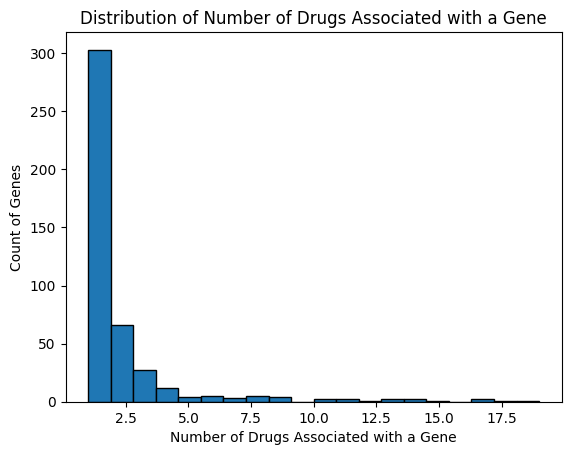

In [11]:
#For each gene, how many drugs it's associated with
#For each gene, how many SNPs

NumberOfDrugsInGene = summary_df.groupby("GENE_SYMBOL")["DRUG_NAME"].nunique()

plt.hist(NumberOfDrugsInGene, bins=20, edgecolor="black")
plt.xlabel("Number of Drugs Associated with a Gene")     
plt.ylabel("Count of Genes")                             
plt.title("Distribution of Number of Drugs Associated with a Gene")
plt.show()


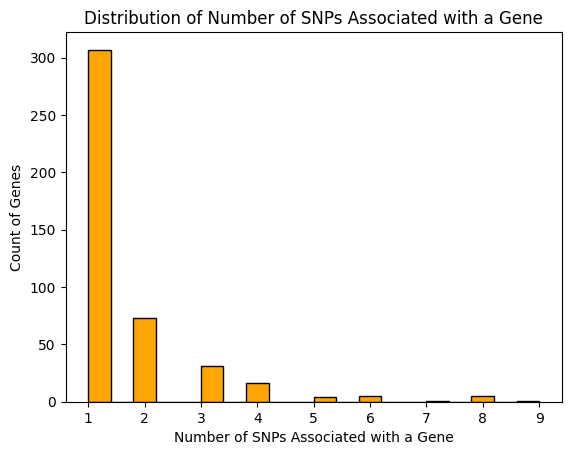

In [12]:
NumberOfSNPsInGene = filtered_df.groupby("GENE_SYMBOL")["dbSNP_ID"].nunique()
plt.hist(NumberOfSNPsInGene, bins=20, edgecolor="black", color='orange')
plt.xlabel("Number of SNPs Associated with a Gene")     
plt.ylabel("Count of Genes")                             
plt.title("Distribution of Number of SNPs Associated with a Gene")
plt.show()

6. New feature

How many of the dbsnp ids from 23andMe report are not present in Variant/Haplotypes annotation file 

In [12]:
rs_23andme = set(df23["rsid"].dropna())
#print(rs_23andme)
rs_pharmgkb = set(pharm_rs["Variant/Haplotypes"].dropna())
#print(rs_pharmgkb)

In [13]:
#rsIDs present in only 23andme report 
ids_only_23andme = rs_23andme - rs_pharmgkb

print("IDs present only in 23andMe:", len(ids_only_23andme))


df_only_23andme = df23[df23["rsid"].isin(ids_only_23andme)][["rsid", "chrom", "pos", "allele_23andme"]]
df_only_23andme

df_only_23andme.to_csv("23andme_unannotated_snps.tsv", index=False, sep='\t')


##These are variants in this individual’s genome that have not yet been studied for drug response according to PharmGKB
#Biologically this is relevant because it shows the gap in pharmacogenomic knowledge for this individual i.e 
#these unannotated SNPs represent variants in genes affecting drug response that either have not yet been studied or
#haven't been reported, thus providing insights into areas for further research

IDs present only in 23andMe: 636589


New Feature 2 - Penelope Lialios

Identifying mismatches between the 23andMe sample and the PharmGKB risk alleles. By determining if the sample genotype matches the PharmGKB risk alleles, we can determine if that specific drug would be effective on that person. 

AI use: helped deal with the PharmGKB multiple genotypes cases (how some cases have CC+CT) 

In [15]:
#Only looking at significant associations 
#Adds a column with match status 

#Fixes index errror
final_output_df_feature2 = final_output_df.copy().reset_index(drop=True)

final_output_df_feature2["match_status"] = ""

for i in range(len(final_output_df_feature2)):
    
    pharm_allele = str(final_output_df_feature2.loc[i, "ALLELE_PharmGKB"]).upper().strip()
    sample_allele = str(final_output_df_feature2.loc[i, "ALLELE_23andme"]).upper().strip()


    #Handle haploid vs diploid sample
    if len(sample_allele) == 1:
        sample_haploid = True
        sample_sorted = sample_allele
    else:
        sample_haploid = False
        sample_sorted = "".join(sorted(sample_allele))

    #Split PharmGKB by +
    genotype_options = [g.strip() for g in pharm_allele.split("+") if g.strip() != ""]

    match_found = False

    for g in genotype_options:
        g = g.strip()

        #Homozygous (CC) or heterozygous (CT)
        if len(g) == 2:  
            if sample_haploid:
              #Haploid sample: match if alleles in PharmGKB genotype is in sample
                if any(allele in sample_sorted for allele in g):
                    match_found = True
                    break
            else:
                #Diploid sample: match if any alleles in PharmGKB genotype are in sample
                if all(allele in sample_sorted for allele in g):
                    match_found = True
                    break
        elif len(g) == 1:  #Single allele 
            if g in sample_sorted:
                match_found = True
                break

    final_output_df_feature2.loc[i, "match_status"] = "match" if match_found else "mismatch"

final_output_df_feature2



,dbSNP_ID,GENE_SYMBOL,DRUG_NAME,NOTES,SENTENCE,ALLELE_PharmGKB,ALLELE_23andme,match_status
0,rs2651899,PRDM16,Selective serotonin (5HT1) agonists,"""Hence, the following risk alleles were determ...",Allele C is associated with increased response...,C,T,mismatch
1,rs1801131,MTHFR,oxaliplatin,Statistics given as trend for increased overal...,Genotypes GG + GT are associated with increase...,GG + GT,T,match
2,rs1801131,MTHFR,"Vitamin B-complex, Incl. Combinations",Please note that allele has been complemented ...,Allele G is associated with increased response...,G,T,mismatch
3,rs1801131,MTHFR,"fluorouracil, leucovorin, oxaliplatin",NaN,Allele G is associated with increased response...,G,T,mismatch
4,rs1801131,MTHFR,methotrexate,Patients with the TT genotype had significantl...,Genotype TT is associated with decreased respo...,TT,T,match
...,...,...,...,...,...,...,...,...
1430,rs502434,GRIA3,"Selective serotonin reuptake inhibitors, venla...",Regression model looking at interaction betwee...,Genotype CC is associated with decreased respo...,CC,T,mismatch
1431,rs3810651,GABRQ,venlafaxine,Those with the AA/AT genotype are more likely ...,Genotypes AA + AT are associated with increase...,AA + AT,T,match
1432,rs17435,MECP2,"cisplatin, fluorouracil, mitoxantrone",The study described this variant within the ME...,Allele A is associated with response to cispla...,A,T,mismatch
1433,rs1734787,MECP2,"cisplatin, fluorouracil, mitoxantrone",The study described this variant within the ME...,Allele A is associated with response to cispla...,A,A,match


This feature allows us to directly compare the sample's variants from 23andMe to known drug response variants. This can help with predicting accuracy of drugs for certain people. This feature handles the single alleles reported in 23andMe and can compare it to single alleles and multi-genotype scenarios which is important when using two different sources to handle all the different cases. This data can be used to quantify the prevalence of actionable variants across the dataset which provides insight into population-level patterns. 

New Feature 3: Shreya Shanbhog

Gene-Level Drug Burden Analysis

Description of the Feature

This feature summarizes the individual’s pharmacogenomic profile at the gene level instead of the variant level. After filtering the dataset to only include significant efficacy-related associations, all variants were grouped by their gene (GENE_SYMBOL). For each gene, the number of significant SNPs was counted, the list of drugs influenced by those variants was collected, and all corresponding dbSNP IDs were compiled.

This produces a table showing:

1. num_significant_variants – how many pharmacogenomically relevant variants are present in the gene

2. drugs_affected – which drugs are impacted by those variants

3. rsIDs – all involved SNP IDs for that gene

The output helps highlight which genes carry the most pharmacogenetically important variants for this person. This is biologically meaningful because certain genes play central roles in drug metabolism (e.g., CYP450 family). A higher burden of efficacy-related variants in a gene may indicate a greater chance of altered drug response for medications metabolized by that gene.

The final summary file is saved as 23andme_gene_burden_summarized.tsv.

AI assistance was used to help clarify how to structure comments for readability and improve wording of the description

In [15]:
# Copying to avoid modifying original
df_burden = filtered_df.copy()

In [16]:
# Counting significant variants per gene
gene_burden = (
    df_burden.groupby("GENE_SYMBOL")
    .agg({
        "dbSNP_ID": "count", # Counting how many dbSNP_ID rows exist per gene
        "DRUG_NAME": lambda x: ";".join(sorted(set(x))),
    })
    .rename(columns={"dbSNP_ID": "num_significant_variants",
                     "DRUG_NAME": "drugs_affected"})     # Rename the output columns to more meaningful names
)

# Add list of SNPs per gene
gene_burden["rsIDs"] = (
    df_burden.groupby("GENE_SYMBOL")["dbSNP_ID"]
    .apply(lambda x: ";".join(sorted(x.unique())))
) # Take unique SNP IDs for that gene, sort them, and join with ";"

gene_burden.reset_index(inplace=True) # Resetting the index turns it back into a normal column.

# Save summary
gene_burden.to_csv("23andme_gene_burden_summarized.tsv", sep="\t", index=False)

gene_burden


,GENE_SYMBOL,num_significant_variants,drugs_affected,rsIDs
0,ABCA1,4,"atorvastatin, rosuvastatin, simvastatin;fenofi...",rs2230806;rs2230808
1,ABCB1,25,antidepressants;antipsychotics;carbamazepine;c...,rs10248420;rs1128503;rs1922242;rs7787082
2,ABCC1,6,"lamivudine, lopinavir, ritonavir, zidovudine;m...",rs212091;rs2238476;rs246240;rs28364006;rs35592...
3,ABCC2,11,"CHOP, rituximab;antiepileptics;atorvastatin;at...",rs3740066;rs717620;rs8187710
4,ABCC4,2,imatinib;latanoprost,rs11568658;rs9561765
...,...,...,...,...
438,XRCC3,2,"Platinum compounds;cisplatin, docetaxel, irino...",rs861539
439,XRCC4,1,"fluorouracil, Platinum compounds, radiotherapy",rs2075685
440,ZNF432,1,"budesonide, corticosteroids, fluticasone / sal...",rs3752120
441,ZNF697,1,"interferon beta-1a, interferon beta-1b",rs10494227
